In [1]:
#12.1 (b)
import numpy as np

def get_ising_hamiltonian(N, lam):
    #pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)

#construct 2^N x 2^N matrix representing an operator acting on a specific site
    def get_site_operator(op, site):
        mat = np.array([[1.0]], dtype=complex)
        for i in range(N):
            if i == site:
                mat = np.kron(mat, op)
            else:
                mat = np.kron(mat, np.eye(2))
        return mat

#initialize empty Hamiltonian matrix
    H = np.zeros((2**N, 2**N), dtype=complex)

    for n in range(N):
#periodic boundary conditions
        next_n = (n + 1) % N

#interaction term: sigma^x_n * sigma^x_{n+1}
        term_x = get_site_operator(sx, n) @ get_site_operator(sx, next_n)

#transverse field term: lambda * sigma^z_n
        term_z = lam * get_site_operator(sz, n)

        H += term_x + term_z

    return H

Computing gaps for lambda = 0.8...
Computing gaps for lambda = 1.0...
Computing gaps for lambda = 1.2...


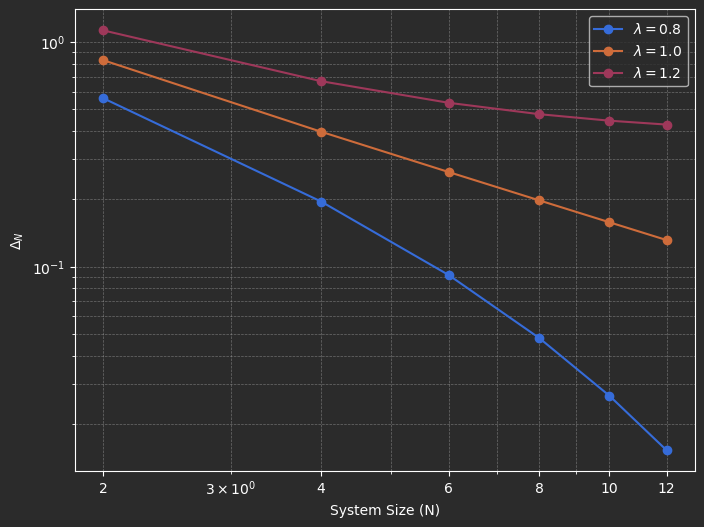

In [2]:
#12.1 (c) - dauert ca. 3min
import matplotlib.pyplot as plt

Ns = [2, 4, 6, 8, 10, 12]
lambdas = [0.8, 1.0, 1.2]

#dictionary to hold computed gaps
gaps_dict = {lam: [] for lam in lambdas}

#compute gaps
for lam in lambdas:
    print(f"Computing gaps for lambda = {lam}...")
    for N in Ns:
        H = get_ising_hamiltonian(N, lam)

        #compute eigenvalues for a hermitian matrix
        eigenvalues = np.linalg.eigvalsh(H)

        eigenvalues = np.sort(eigenvalues)

        #first gap is the difference between the lowest two eigenvalues
        gap = eigenvalues[1] - eigenvalues[0]
        gaps_dict[lam].append(gap)

#plotting the results double-log
plt.figure(figsize=(8, 6))

for lam in lambdas:
    plt.loglog(Ns, gaps_dict[lam], 'o-', label=f'$\lambda = {lam}$')

plt.xlabel('System Size (N)')
plt.ylabel('$\Delta_N$')
plt.xticks(Ns, [str(n) for n in Ns])  # Use explicit string labels for clarity
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()